In [4]:
from google.colab import files
uploaded = files.upload()  # Upload Midterm_53_group.csv when prompted

Saving Midterm_53_group.csv to Midterm_53_group (1).csv


Step 1 — Install Libraries

In [5]:
pip install plotly openpyxl scikit-learn

Step 2 — Load & Explore Data

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Midterm_53_group.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nNull values:")
print(df.isnull().sum())

Shape: (394136, 7)

First 5 rows:
       Time           Source  No.      Destination Protocol  Length  \
0  0.000000    192.167.8.166    1  192.167.255.255     NBNS      92   
1  0.784682    192.167.8.166    2  192.167.255.255     NBNS      92   
2  1.169060  VMware_8a:5c:e6    3        Broadcast      ARP      60   
3  2.167949  VMware_8a:5c:e6    4        Broadcast      ARP      60   
4  3.170095  VMware_8a:5c:e6    5        Broadcast      ARP      60   

                                      Info  
0                   Name query NB WPAD<00>  
1                   Name query NB WPAD<00>  
2  Who has 192.167.7.175? Tell 192.167.0.1  
3  Who has 192.167.7.175? Tell 192.167.0.1  
4  Who has 192.167.7.175? Tell 192.167.0.1  

Column names:
['Time', 'Source', 'No.', 'Destination', 'Protocol', 'Length', 'Info']

Data types:
Time           float64
Source          object
No.              int64
Destination     object
Protocol        object
Length           int64
Info            object
dtype: ob

 Step 3 — Data Cleaning

In [7]:
# Drop nulls and duplicates
df = df.dropna()
df = df.drop_duplicates()

# Encode categorical columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df['Source_enc'] = le.fit_transform(df['Source'].astype(str))
df['Destination_enc'] = le.fit_transform(df['Destination'].astype(str))
df['Protocol_enc'] = le.fit_transform(df['Protocol'].astype(str))

print(f"Clean dataset shape: {df.shape}")
print(df[['Source_enc', 'Destination_enc', 'Protocol_enc', 'Length']].head())

Clean dataset shape: (394136, 10)
   Source_enc  Destination_enc  Protocol_enc  Length
0         183              152             7      92
1         183              152             7      92
2         347              303             0      60
3         347              303             0      60
4         347              303             0      60


 Step 4 — Exploratory Data Analysis

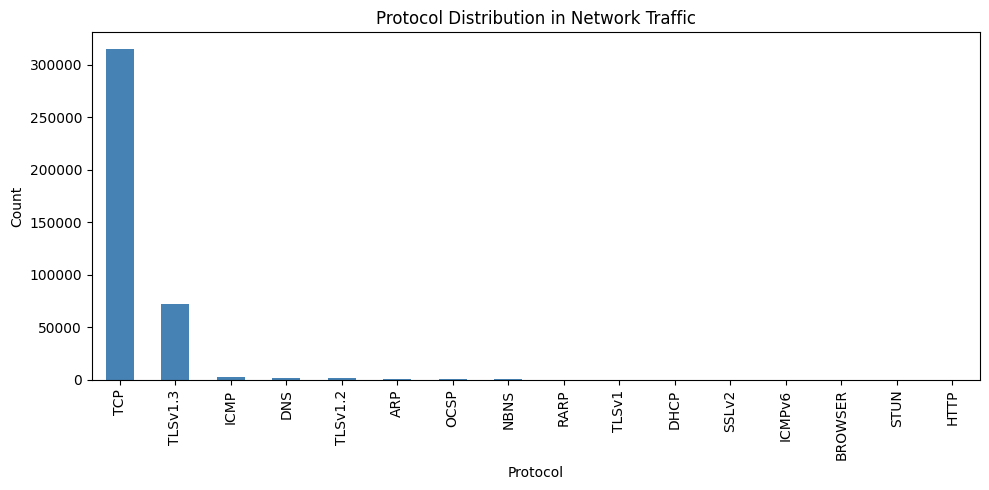

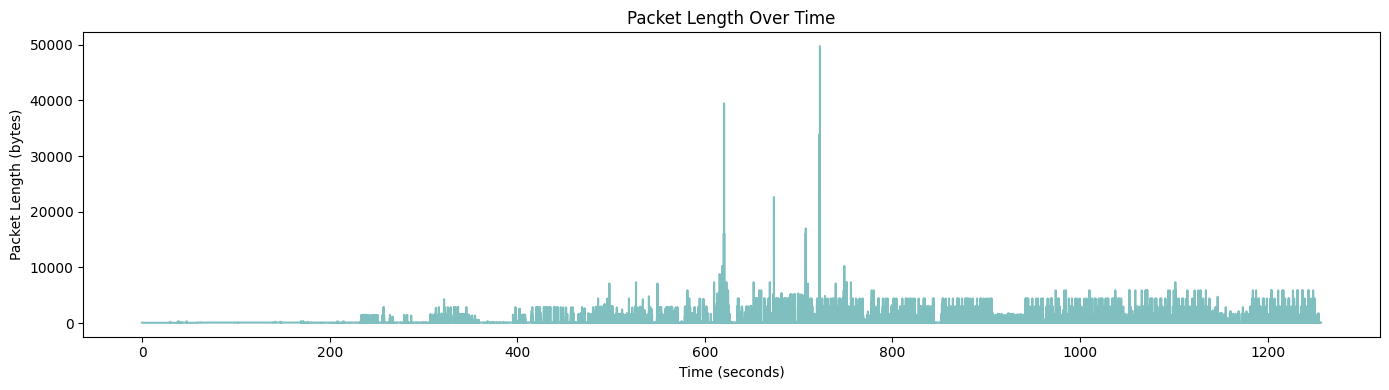

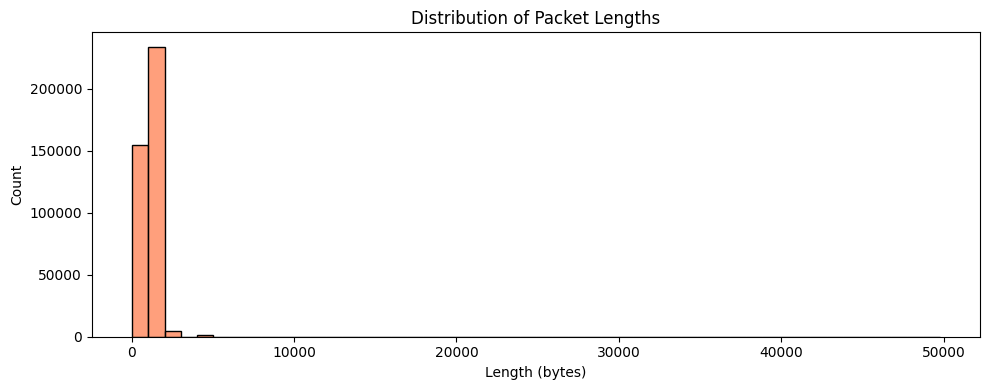

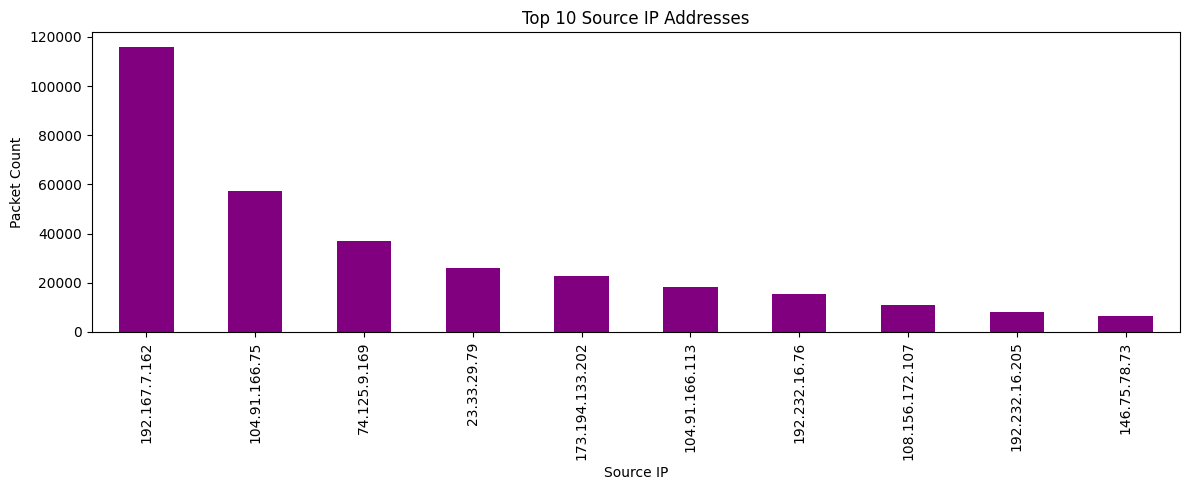

In [8]:
# 1. Protocol distribution
plt.figure(figsize=(10, 5))
df['Protocol'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Protocol Distribution in Network Traffic')
plt.xlabel('Protocol')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('protocol_distribution.png')
plt.show()

# 2. Packet length over time
plt.figure(figsize=(14, 4))
plt.plot(df['Time'], df['Length'], color='teal', alpha=0.5)
plt.title('Packet Length Over Time')
plt.xlabel('Time (seconds)')
plt.ylabel('Packet Length (bytes)')
plt.tight_layout()
plt.savefig('packet_length_over_time.png')
plt.show()

# 3. Packet length distribution
plt.figure(figsize=(10, 4))
sns.histplot(df['Length'], bins=50, color='coral')
plt.title('Distribution of Packet Lengths')
plt.xlabel('Length (bytes)')
plt.tight_layout()
plt.savefig('length_distribution.png')
plt.show()

# 4. Top 10 source IPs
plt.figure(figsize=(12, 5))
df['Source'].value_counts().head(10).plot(kind='bar', color='purple')
plt.title('Top 10 Source IP Addresses')
plt.xlabel('Source IP')
plt.ylabel('Packet Count')
plt.tight_layout()
plt.savefig('top_sources.png')
plt.show()

 Step 5 — Anomaly Detection Model

In [10]:
from sklearn.ensemble import IsolationForest

# Features for anomaly detection
features = ['Time', 'No.', 'Length', 'Source_enc', 'Destination_enc', 'Protocol_enc']
X = df[features]

# Train Isolation Forest
model = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
df['anomaly_score'] = model.fit_predict(X)

# Label results
df['anomaly'] = df['anomaly_score'].apply(lambda x: 'Anomaly' if x == -1 else 'Normal')

print("\nAnomaly Detection Results:")
print(df['anomaly'].value_counts())

print("\nSample Anomalous Packets:")
print(df[df['anomaly'] == 'Anomaly'][['Time', 'Source', 'Destination', 'Protocol', 'Length']].head(10))


Anomaly Detection Results:
anomaly
Normal     374439
Anomaly     19697
Name: count, dtype: int64

Sample Anomalous Packets:
        Time           Source      Destination Protocol  Length
0   0.000000    192.167.8.166  192.167.255.255     NBNS      92
1   0.784682    192.167.8.166  192.167.255.255     NBNS      92
2   1.169060  VMware_8a:5c:e6        Broadcast      ARP      60
3   2.167949  VMware_8a:5c:e6        Broadcast      ARP      60
4   3.170095  VMware_8a:5c:e6        Broadcast      ARP      60
5   8.846485  VMware_8a:5c:e6        Broadcast      ARP      60
6   9.848273  VMware_8a:5c:e6        Broadcast      ARP      60
7  10.850213  VMware_8a:5c:e6        Broadcast      ARP      60
8  16.530105  VMware_8a:5c:e6        Broadcast      ARP      60
9  17.532040  VMware_8a:5c:e6        Broadcast      ARP      60


Step 6 — Interactive Dashboard

In [11]:
import os
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Sample 1000 rows only — keeps file small
df_small = df.sample(n=1000, random_state=42)

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'Packet Length vs Time (Anomalies Highlighted)',
        'Protocol Distribution',
        'Anomaly Count',
        'Top 10 Source IPs by Packet Count'
    ),
    specs=[
        [{"type": "scatter"}, {"type": "bar"}],
        [{"type": "domain"}, {"type": "bar"}]
    ]
)

# Plot 1 — Scatter
colors = df_small['anomaly'].map({'Normal': 'steelblue', 'Anomaly': 'red'})
fig.add_trace(
    go.Scatter(x=df_small['Time'], y=df_small['Length'],
               mode='markers',
               marker=dict(color=colors, size=3, opacity=0.6),
               name='Packets'),
    row=1, col=1
)

# Plot 2 — Protocol bar chart
proto_counts = df['Protocol'].value_counts().head(10)
fig.add_trace(
    go.Bar(x=proto_counts.index, y=proto_counts.values,
           marker_color='teal', name='Protocol'),
    row=1, col=2
)

# Plot 3 — Anomaly pie chart
anomaly_counts = df['anomaly'].value_counts()
fig.add_trace(
    go.Pie(labels=anomaly_counts.index, values=anomaly_counts.values,
           marker=dict(colors=['steelblue', 'red']), name='Anomaly'),
    row=2, col=1
)

# Plot 4 — Top source IPs
top_sources = df['Source'].value_counts().head(10)
fig.add_trace(
    go.Bar(x=top_sources.index, y=top_sources.values,
           marker_color='purple', name='Source IPs'),
    row=2, col=2
)

fig.update_layout(
    height=800,
    title_text='IT Network Traffic — Anomaly Detection Dashboard',
    showlegend=False
)

# Save with CDN — keeps file under 25MB for GitHub
fig.write_html('anomaly_dashboard.html',
               include_plotlyjs='cdn',
               full_html=True)

fig.show()
print(f"✅ Dashboard saved! Size: {os.path.getsize('anomaly_dashboard.html')/1024:.1f} KB")

✅ Dashboard saved! Size: 35.9 KB


Step 7 — Export to Excel

In [12]:
# Sample 10000 rows for Excel
df_excel = df.sample(n=10000, random_state=42).reset_index(drop=True)

with pd.ExcelWriter('anomaly_results.xlsx', engine='openpyxl') as writer:

    # Sheet 1 — All sampled results
    df_excel.to_excel(writer, sheet_name='All Traffic', index=False)

    # Sheet 2 — Anomalies only
    df_excel[df_excel['anomaly'] == 'Anomaly'].to_excel(
        writer, sheet_name='Anomalies Only', index=False)

    # Sheet 3 — Summary stats
    summary = pd.DataFrame({
        'Metric': [
            'Total Packets Analysed',
            'Normal Packets',
            'Anomalous Packets',
            'Anomaly Percentage',
            'Most Common Protocol',
            'Average Packet Length',
            'Max Packet Length'
        ],
        'Value': [
            len(df),
            len(df[df['anomaly'] == 'Normal']),
            len(df[df['anomaly'] == 'Anomaly']),
            f"{round(len(df[df['anomaly']=='Anomaly'])/len(df)*100, 2)}%",
            df['Protocol'].value_counts().idxmax(),
            round(df['Length'].mean(), 2),
            df['Length'].max()
        ]
    })
    summary.to_excel(writer, sheet_name='Summary', index=False)

print("✅ Excel report saved!")
print("   → Sheet 1: All Traffic (10,000 rows)")
print("   → Sheet 2: Anomalies Only")
print("   → Sheet 3: Summary Statistics")

✅ Excel report saved!
   → Sheet 1: All Traffic (10,000 rows)
   → Sheet 2: Anomalies Only
   → Sheet 3: Summary Statistics


 Step 8 — Download All Files from Colab

In [13]:
from google.colab import files

files.download('anomaly_dashboard.html')
files.download('anomaly_results.xlsx')
files.download('protocol_distribution.png')
files.download('packet_length_over_time.png')
files.download('length_distribution.png')
files.download('top_sources.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>